<a href="https://colab.research.google.com/github/enoklestari/Dataset_Project/blob/main/Adaptasi_Paper_T_S_Fuzzy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

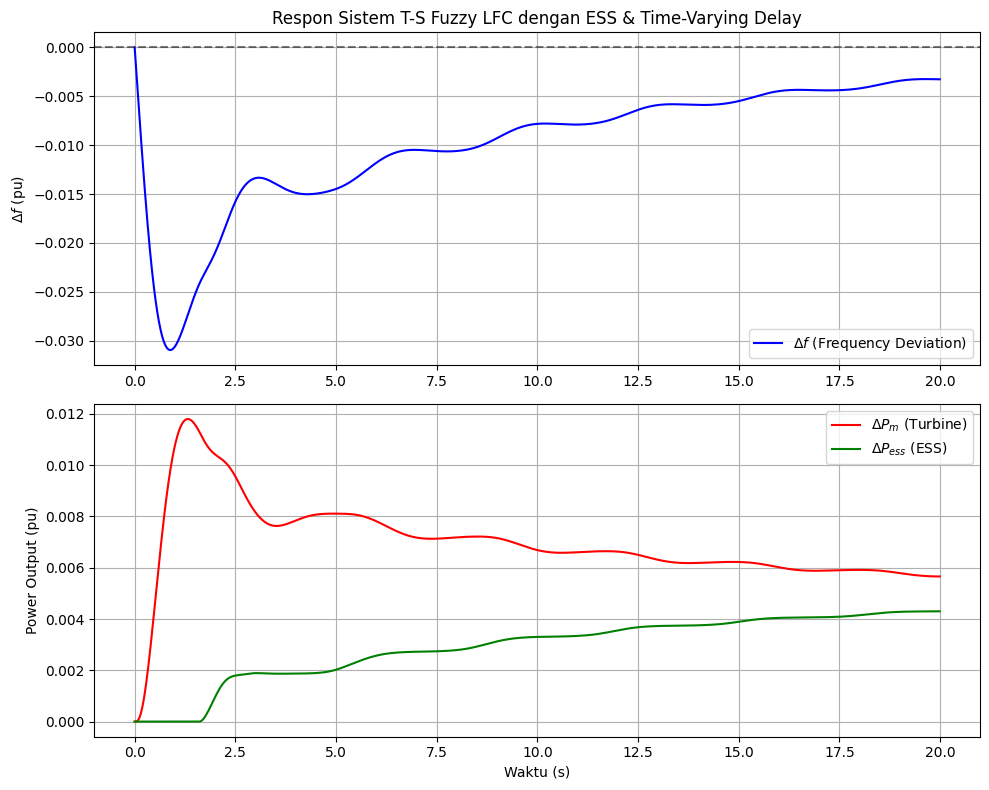

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# PARAMETER SISTEM (Berdasarkan Paper Jin Yang et al., 2024)
# =================================================================
M = 0.1667    # Inersia generator
D = 0.0083    # Koefisien damping
Tg = 0.08     # Time constant governor
Tt = 0.3      # Time constant turbin
Te = 0.1      # Time constant ESS
R = 2.4       # Speed droop
beta = 0.425  # Faktor bias frekuensi
alpha1 = 0.5  # Parameter partisipasi Governor
alpha2 = 0.5  # Parameter partisipasi ESS

dt = 0.01
t_final = 20
t_vec = np.arange(0, t_final, dt)

def get_delay(t):
    # Sesuai Case Study 2
    return 0.8 * (np.sin(t)**2) + 0.8

# x = [df, dPm, dPg, dPess, int_ACE]
num_states = 5
x = np.zeros((num_states, len(t_vec)))
u_history = np.zeros(len(t_vec))

phi = 0.01  # Gangguan beban phi(t)
Kp, Ki = 0.2, 0.1 # Gain kontroler PI

for i in range(len(t_vec) - 1):
    t = t_vec[i]
    df_curr = x[0, i]
    ACE = beta * df_curr
    int_ACE = x[4, i]

    u_curr = -Kp * ACE - Ki * int_ACE
    u_history[i] = u_curr

    tau = get_delay(t)
    t_target = t - tau
    if t_target <= 0:
        u_delayed = 0
    else:
        idx_delayed = int(t_target / dt)
        u_delayed = u_history[idx_delayed]

    # Update State Dynamics
    x[0, i+1] = x[0, i] + dt * ((1/M) * (x[1, i] + x[3, i] - D*x[0, i] - phi))
    x[1, i+1] = x[1, i] + dt * ((1/Tt) * (x[2, i] - x[1, i]))
    x[2, i+1] = x[2, i] + dt * ((1/Tg) * (alpha1 * u_delayed - (1/R)*x[0, i] - x[2, i]))
    x[3, i+1] = x[3, i] + dt * ((1/Te) * (alpha2 * u_delayed - x[3, i]))
    x[4, i+1] = x[4, i] + dt * ACE

# =================================================================
# VISUALISASI HASIL (DENGAN PERBAIKAN RAW STRING 'r')
# =================================================================
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
# Menambahkan 'r' sebelum string agar LaTeX simbol \Delta terbaca benar
plt.plot(t_vec, x[0, :], 'b', linewidth=1.5, label=r'$\Delta f$ (Frequency Deviation)')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.ylabel(r'$\Delta f$ (pu)')
plt.title('Respon Sistem T-S Fuzzy LFC dengan ESS & Time-Varying Delay')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_vec, x[1, :], 'r', label=r'$\Delta P_m$ (Turbine)')
plt.plot(t_vec, x[3, :], 'g', label=r'$\Delta P_{ess}$ (ESS)')
plt.ylabel('Power Output (pu)')
plt.xlabel('Waktu (s)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()